In [172]:
from astropy.io import ascii

import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack, hstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18


import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'tight',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches

# from consolidate_photometry import get_fastspec_fit_catalog_V2


%load_ext autoreload
%autoreload 2

MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.9   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar
    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
from fastspec_funcs import get_fastspecfit_path, measure_photo_batch

In [63]:
# get_fastspec_fit_catalog_V2()

In [7]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
main_all =  Table.read(filename, hdu="MAIN")
fastspec_all =  Table.read(filename, hdu="SPEC_DERIVED")


In [64]:
fib_based_all =  Table.read(filename, hdu="FIBER_BASED")


In [65]:
print(len(main_all), len(fastspec_all))

464153 464153


In [7]:
spectra_h5_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5"

with h5py.File(spectra_h5_path, "r") as f:
    h5_wave = f["WAVE"][:]
    h5_flux = f["FLUX"][:]
    h5_flux_ivar = f["FLUX_IVAR"][:]
    h5_targetid = f["TARGETID"][:]

## Impact of nebular corrections!!

In [82]:
from desi_lowz_funcs import get_stellar_mass_mia

from desi_lowz_funcs import get_contours

In [77]:
fastspec_bgsb = fastspec_all[ (main_all["SAMPLE"] == "BGS_BRIGHT") & (main_all["DWARF_MASKBIT"] == 0) & (main_all["MSTAR_MASKBIT"] == 0) ]
main_bgsb = main_all[ (main_all["SAMPLE"] == "BGS_BRIGHT") & (main_all["DWARF_MASKBIT"] == 0) & (main_all["MSTAR_MASKBIT"] == 0) ]
print(len(fastspec_bgsb))

169763


In [81]:
## we need to just isolate the impact of nebular correction and not any of the other bits

gmag_raw = main_bgsb["MAG_G"].data
rmag_raw = main_bgsb["MAG_R"].data

zred = main_bgsb["Z"].data

gr_raw = gmag_raw - rmag_raw

gmag_corr = gmag_raw + fastspec_bgsb["DELTA_MAG_G_NEB"].data
rmag_corr = rmag_raw + fastspec_bgsb["DELTA_MAG_R_NEB"].data

gr_corr = gmag_corr - rmag_corr

# Uncorrected (contaminated)
logM_raw = get_stellar_mass_mia(gr_raw, gmag_raw, zred)

# Fully corrected (your fiducial)
logM_corr = get_stellar_mass_mia(gr_corr, gmag_corr, zred)

halpha_ew = fastspec_bgsb["HALPHA_EW"].data

halpha_ew_mask = ( (fastspec_bgsb["HALPHA_EW"].data * np.sqrt(fastspec_bgsb["HALPHA_EW_IVAR"]) ) > 3) 

print( np.sum(halpha_ew_mask)/len(halpha_ew_mask) )

0.9509728268232771


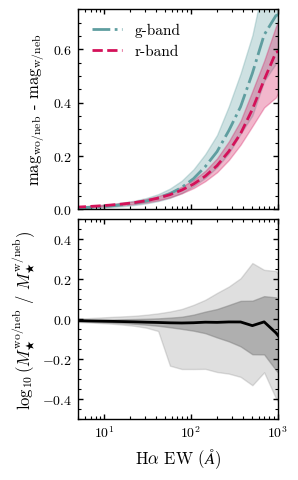

In [176]:
import numpy as np


fig, ax = make_subplots(ncol=1, nrow=2, 
                        return_fig=True,
                        row_spacing=[MARGIN_LABEL, MARGIN_SHARED, MARGIN_PAD],  # [bottom, between, top],
                         col_spacing=[MARGIN_LABEL, MARGIN_PAD])                  # [left, right]
                       
# Log-spaced x bins
x_bins = np.logspace(np.log10(4), np.log10(1.5e3), 20)

col0 = "#1A85FF"
col1 = "#D41159"

# Panel 0
x0 = halpha_ew[halpha_ew_mask]
y0 = fastspec_bgsb["DELTA_MAG_G_NEB"].data[halpha_ew_mask]
c0 = get_contours(x0, y0, x_bins, sigs=True)
col0 = "cadetblue"
ax[1].plot(c0["bin_cents"], c0["median"], color=col0, lw=2,ls="-.", label  = "g-band")
ax[1].fill_between(c0["bin_cents"], c0["sig1_low"], c0["sig1_high"], alpha=0.3, color=col0)
# ax[1].fill_between(c0["bin_cents"], c0["sig2_low"], c0["sig2_high"], alpha=0.1, color=col0)


y0 = fastspec_bgsb["DELTA_MAG_R_NEB"].data[halpha_ew_mask]
c0 = get_contours(x0, y0, x_bins, sigs=True)
col0 = "cadetblue"
ax[1].plot(c0["bin_cents"], c0["median"], color=col1, lw=2,ls="--", label = "r-band")
ax[1].fill_between(c0["bin_cents"], c0["sig1_low"], c0["sig1_high"], alpha=0.3, color=col1)
# ax[1].fill_between(c0["bin_cents"], c0["sig2_low"], c0["sig2_high"], alpha=0.1, color=col1)

ax[1].tick_params(labelbottom=False)
ax[1].legend()
# Panel 1
# x1 = cat["HALPHA_EW"].data #[snr_mask]
# y1 = cat["DELTA_MAG_R_NEB"].data #[snr_mask]
# # ax[1].scatter(x1, y1, s=1, alpha=0.3)
# col1 = "firebrick"
# c1 = get_contours(x1, y1, x_bins, sigs=True)
# ax[1].plot(c1["bin_cents"], c1["median"], color="k", lw=2)
# ax[1].fill_between(c1["bin_cents"], c1["sig1_low"], c1["sig1_high"], alpha=0.5, color=col1)
# ax[1].fill_between(c1["bin_cents"], c1["sig2_low"], c1["sig2_high"], alpha=0.25, color=col1)

    
ax[1].set_ylim([0, .75])
ax[1].set_ylabel(r"mag$_{\rm wo/neb}$ - mag$_{\rm w/neb}$")

# Panel mstar
x2 = halpha_ew[halpha_ew_mask]
y2 = logM_corr[halpha_ew_mask] - logM_raw[halpha_ew_mask]
col2 = "grey"
c2 = get_contours(x2, y2, x_bins, sigs=True)
ax[0].plot(c2["bin_cents"], c2["median"], color="k", lw=2)
ax[0].fill_between(c2["bin_cents"], c2["sig1_low"], c2["sig1_high"], alpha=0.5, color=col2)
ax[0].fill_between(c2["bin_cents"], c2["sig2_low"], c2["sig2_high"], alpha=0.25, color=col2)

# xgrid = np.logspace(np.log10(5), 3, 100)
# make_alternating_plot(ax[0], xgrid, 0 * xgrid, dash_len=1, color_1="yellowgreen", color_2="k", lw=1)

ax[0].set_xlabel(r"H$\alpha$ EW ($\AA$)")
    
ax[0].set_ylim([-0.5, 0.5])

ax[0].set_ylabel(r"$\log_{10}( M_{\bigstar}^{\rm wo/neb}$ / $M_{\bigstar}^{\rm w/neb} )$")

for axi in ax:
    axi.set_xlim([5, 1e3])    
    axi.set_xscale("log")


plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/neb_corr_bgsb_plot.pdf")

plt.show()


## K correction validation plots!

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import cmasher as cmr
from desi_lowz_funcs import g_kcorr, r_kcorr, get_contours, make_alternating_plot


In [114]:
main_all[:2]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,LOG_MSTAR_M24_ERR,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MSTAR_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,ASSOCIATED_TARGETIDS,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,DIST_SOURCE,PROPERTY_SOURCE_TARGETID
int64,bytes7,bytes6,int32,float64,float64,int32,float64,float64,float64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes10,int32,int32,bytes13,bool,float64,float64[2],bool,object,int64,bool,bytes10,int64
39627066986994125,sv1,bright,34722,0.032918604316881296,98.85089745232835,0,0.03264401958193863,58.82791003142589,-31.167992883134954,58.82791003142589,-31.167992883134954,DESI J058.8279-31.1679,148.21792602539062,8.843826293945312,0.04251172982109555,18.319110870361328,17.939651489257812,17.730533599853516,18.319110870361328,17.939651489257812,17.730533599853516,BGS_BRIGHT,0,0,TRACTOR_OG,False,7.116967678070068,0.6592394709587097 .. -87.19556427001953,False,[39627066986994125],39627066986994125,True,V_CMB,39627066986994125
39627066995376721,sv1,bright,34721,0.06713081686670527,444.1444324851036,0,0.06685584372174991,59.235244922847556,-31.360982247692228,59.235244922847556,-31.360982247692228,DESI J059.2352-31.3609,311.04266357421875,9.242656707763672,0.02500834480091534,19.275266647338867,18.767732620239258,18.4816951751709,19.275266647338867,18.767732620239258,18.4816951751709,BGS_BRIGHT,0,0,TRACTOR_OG,False,1.832580804824829,0.9732345342636108 .. -16.84249496459961,False,[39627066995376721],39627066995376721,True,V_CMB,39627066995376721


In [115]:
fastspec_all[:2]

TARGETID,RA,DEC,SNR_B,SNR_R,SNR_Z,APERCORR,APERCORR_G,APERCORR_R,APERCORR_Z,OII_3726_FLUX,OII_3726_FLUX_IVAR,OII_3729_FLUX,OII_3729_FLUX_IVAR,OIII_4363_FLUX,OIII_4363_FLUX_IVAR,HEII_4686_FLUX,HEII_4686_FLUX_IVAR,HBETA_FLUX,HBETA_FLUX_IVAR,OIII_4959_FLUX,OIII_4959_FLUX_IVAR,OIII_5007_FLUX,OIII_5007_FLUX_IVAR,HEI_5876_FLUX,HEI_5876_FLUX_IVAR,NII_6548_FLUX,NII_6548_FLUX_IVAR,HALPHA_FLUX,HALPHA_FLUX_IVAR,HALPHA_BROAD_FLUX,HALPHA_BROAD_FLUX_IVAR,NII_6584_FLUX,NII_6584_FLUX_IVAR,SII_6716_FLUX,SII_6716_FLUX_IVAR,SII_6731_FLUX,SII_6731_FLUX_IVAR,SIII_9069_FLUX,SIII_9069_FLUX_IVAR,SIII_9532_FLUX,SIII_9532_FLUX_IVAR,HALPHA_BOXFLUX,HALPHA_BOXFLUX_IVAR,HALPHA_EW,HALPHA_EW_IVAR,DN4000,DN4000_OBS,DN4000_IVAR,DN4000_MODEL,VDISP,VDISP_IVAR,LOGMSTAR,MAG_G_FIBER_NOEMI,MAG_R_FIBER_NOEMI,MAG_G_FIBER_NOEMI_ERR,MAG_R_FIBER_NOEMI_ERR,MAG_G_DECAM_MODEL_NOEMI,MAG_R_DECAM_MODEL_NOEMI,MAG_G_DECAM_MODEL_WEMI,MAG_R_DECAM_MODEL_WEMI,MAG_G_BASS_MODEL_WEMI,MAG_R_BASS_MODEL_WEMI,MAG_G_SDSS_MODEL_NOEMI,MAG_R_SDSS_MODEL_NOEMI,MAG_G_SDSS_Z0_MODEL_NOEMI,MAG_R_SDSS_Z0_MODEL_NOEMI,DELTA_MAG_G_BASS2DECAM,DELTA_MAG_R_BASS2DECAM,DELTA_MAG_G_NEB,DELTA_MAG_R_NEB,DELTA_MAG_G_DECAM2SDSS,DELTA_MAG_R_DECAM2SDSS,DELTA_MAG_G_KCORR,DELTA_MAG_R_KCORR,LOG_SFR_HALPHA,LOG_SFR_HALPHA_ERR,LOG_MSTAR_24_FIBER,LOG_HALPHA_SFR_FIBER,Z_GAS_R23_N2
int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64
39627066986994125,58.82791003142589,-31.167992883134954,0.7362137,1.4110432,1.4763778,17.617802,16.742657,18.288889,17.617802,0.13864987,0.0036776955,1.2419373,0.003478581,0.0038752842,0.04712536,8.606093,0.10930019,3.6840034,0.12549414,2.1664715,0.12482052,6.525919,0.13526016,5.365553,0.25182992,1.139345,0.45386365,13.020986,0.5125305,0.0,0.0,3.3743422,0.46464396,6.9175406,0.40019593,4.389449,0.42514646,3.668044,0.1432467,0.0,0.0,11.785126,0.31097978,16.42255,0.17391735,0.6386112,0.5914388,21.08646,1.2983865,125.0,0.0,8.49248,21.43277905623485,21.14485215847107,0.03289679464639537,0.021915955150509044,21.322842018221912,21.163405013953138,21.302226286983696,21.129652091908632,21.311635537978574,21.128731131004766,21.371494434650785,21.181155038507427,21.34586892648177,21.192801301628606,-0.0,0.0,0.02061573123821603,0.033752922044506306,0.048652416428872414,0.017750024554288757,-0.02562550816901421,0.01164626312117889,-1.3582861284908159,0.06401520193870712,7.462507,-2.871629063169072,--
39627066995376721,59.235244922847556,-31.360982247692228,1.1808858,2.8670604,3.0106993,3.754026,3.3544269,3.754026,3.7849154,11.179523,0.008950349,16.883858,0.009275746,0.0,0.0,3.7785964,0.1884629,8.962078,0.21007247,3.5595784,0.20890892,10.710385,0.20822038,0.015966449,0.74877626,2.0687923,1.2339053,27.447546,0.602077,0.0,0.0,6.107305,1.3206978,5.002391,1.1459689,5.41488,1.2282068,1.2406223,1.0048556,0.0,0.0,27.825468,0.2770433,13.607072,1.4806414,1.5176805,1.3350921,9.755537,1.3523571,156.99861,8.72752e-05,8.935404,20.641814063556886,20.237798478084805,0.0219118061815352,0.010540002590324369,20.58991423240165,20.22444045712625,20.57672636767999,20.209394306012342,20.586093790910418,20.210996925341107,20.628981422299205,20.27585549931249,20.598057943228373,20.262580033212544,-0.0,-0.0,0.013187864721661668,0.015046151113907058,0.039067189897554755,0.05141504218624249,-0.03092347907083237,-0.013275466099948119,-1.1516737705648576,0.026566448148327832,8.56195,-1.8976532064409344,--


In [116]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from desi_lowz_funcs import g_kcorr, r_kcorr
import cmasher as cmr

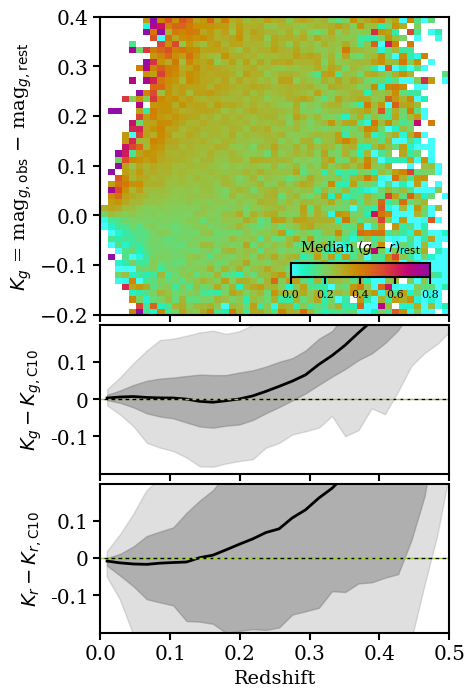

In [41]:
qmask = (main_all["DWARF_MASKBIT"] == 0)

samp_mask = (main_all["SAMPLE"] == "ELG") & qmask

main_samp = main_all[samp_mask]
fastspec_samp = fastspec_all[samp_mask]

zred_max = 0.5
delta_ylim = 0.2

# --- Derived quantities ---
x = main_samp["Z"]
y = -1 * fastspec_samp["DELTA_MAG_G_KCORR"]
c = fastspec_samp["MAG_G_SDSS_Z0_MODEL_NOEMI"] - fastspec_samp["MAG_R_SDSS_Z0_MODEL_NOEMI"]

mag_g_sdss_obs = fastspec_samp["MAG_G_SDSS_MODEL_NOEMI"] #- fastspec_all["DELTA_MAG_G_KCORR"]
mag_r_sdss_obs = fastspec_samp["MAG_R_SDSS_MODEL_NOEMI"] #- fastspec_all["DELTA_MAG_R_KCORR"]
gr_sdss_obs    = mag_g_sdss_obs - mag_r_sdss_obs

g_kcorr_2010 = g_kcorr(gr_sdss_obs, main_samp["Z"])
r_kcorr_2010 = r_kcorr(gr_sdss_obs, main_samp["Z"])

resid_g = g_kcorr_2010 - y
resid_r = r_kcorr_2010 + fastspec_samp["DELTA_MAG_R_KCORR"]

# --- Bin edges ---
x_bins_2d = np.linspace(0, zred_max, 50)
y_bins_2d = np.linspace(-0.2, 0.4, 50)
x_bins_1d = np.linspace(0, zred_max + 0.05, 30)

# --- 2D histogram stat ---
from scipy.stats import binned_statistic_2d

stat, x_edge, y_edge, _ = binned_statistic_2d(
    x, y, c, statistic="median", bins=[x_bins_2d, y_bins_2d]
)

# --- Figure layout ---
fig, axes = plt.subplots(
    3, 1, figsize=(4.5, 8),
    gridspec_kw={"height_ratios": [2, 1, 1]},
    sharex=True
)
fig.subplots_adjust(hspace=0.05)

col_g = "grey"
col_r = "grey"

# ── Panel 0 : 2D histogram ────────────────────────────────────────────────
ax0 = axes[0]
im = ax0.pcolormesh(x_edge, y_edge, stat.T, cmap=cmr.tropical_r, vmin=0., vmax=0.8, rasterized=True)
ax0.set_ylim(-0.2, 0.4)
ax0.set_ylabel(r"$K_g$ = mag$_{g,\rm obs}$ $-$ mag$_{g,\rm rest}$", fontsize=14)
ax0.tick_params(labelbottom=False)

# Colorbar inset — top-right corner, fully inside ax0
cax = inset_axes(ax0,
                 width="40%", height="5%",
                 loc="upper left",
                 bbox_to_anchor=(0.545, -0.825, 1, 1),  # (x0, y0, width, height) in axes fraction
                 bbox_transform=ax0.transAxes,
                 borderpad=0)
cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
cbar.set_label(r"Median $(g-r)_{\rm rest}$", fontsize=10, labelpad=-44)
cbar.ax.tick_params(labelsize=8)
cax.set_zorder(5)   # draw on top of pcolormesh

# ── Panel 1 : g-band residual ─────────────────────────────────────────────
ax1 = axes[1]
cg = get_contours(x.data, resid_g.data, x_bins_1d, sigs=True)
ax1.plot(cg["bin_cents"], cg["median"], color="k", lw=2)
ax1.fill_between(cg["bin_cents"], cg["sig1_low"], cg["sig1_high"],
                 alpha=0.5, color=col_g, label=r"$1\sigma$")
ax1.fill_between(cg["bin_cents"], cg["sig2_low"], cg["sig2_high"],
                 alpha=0.25, color=col_g, label=r"$2\sigma$")
xgrid = np.linspace(0, zred_max, 100)
make_alternating_plot(ax1, xgrid, 0 * xgrid, dash_len=1, color_1="yellowgreen", color_2="k", lw=1)
ax1.set_ylim(-delta_ylim, delta_ylim)
ax1.set_ylabel(r"$K_{g} - K_{g,\rm C10}$", fontsize=14)
ax1.tick_params(labelbottom=False)

# ── Panel 2 : r-band residual ─────────────────────────────────────────────
ax2 = axes[2]
cr = get_contours(x.data, resid_r.data, x_bins_1d, sigs=True)
ax2.plot(cr["bin_cents"], cr["median"], color="k", lw=2)
ax2.fill_between(cr["bin_cents"], cr["sig1_low"], cr["sig1_high"],
                 alpha=0.5, color=col_r, label=r"$1\sigma$")
ax2.fill_between(cr["bin_cents"], cr["sig2_low"], cr["sig2_high"],
                 alpha=0.25, color=col_r, label=r"$2\sigma$")
make_alternating_plot(ax2, xgrid, 0 * xgrid, dash_len=1, color_1="yellowgreen", color_2="k", lw=1)
ax2.set_ylim(-delta_ylim, delta_ylim)
ax2.set_ylabel(r"$K_{r} - K_{r,\rm C10}$", fontsize=14)
ax2.set_xlabel(r"Redshift", fontsize=14)

for axi in [ax1, ax2]:
    axi.set_yticks([-0.1,  0, 0.1])
    # axi.set_yticklabels(["", "-0.05", "0", "0.05", ""])
    axi.set_yticklabels(["-0.1", "0", "0.1"])
    

ax2.set_xlim(0, zred_max)


plt.show()

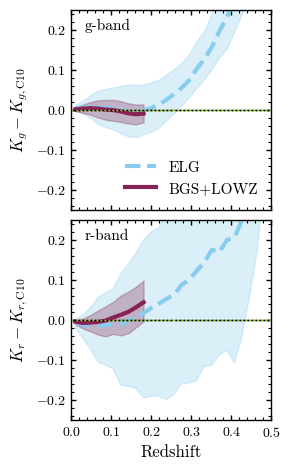

In [175]:
## let us make a separate two panel plot where we show the difference in k correction terms between 
fig,axes = make_subplots(ncol=1,nrow=2,
                         return_fig=True,
                         row_spacing=[MARGIN_LABEL, MARGIN_SHARED, MARGIN_PAD],  # [bottom, between, top],
                         col_spacing=[MARGIN_LABEL, MARGIN_PAD])                  # [left, right]

#this is before we applied the k correction maskbit
qmask = (main_all["DWARF_MASKBIT"] == 0) & (main_all["MSTAR_MASKBIT"] == 0)

samples =  [  (main_all["SAMPLE"] == "ELG") & qmask,
            ((main_all["SAMPLE"] == "BGS_BRIGHT") | (main_all["SAMPLE"] == "BGS_FAINT") | (main_all["SAMPLE"] == "LOWZ") ) & qmask]

zred_max = 0.5
delta_ylim = 0.25

x_bins_1d = np.linspace(0, zred_max + 0.05, 30)

col_g = "grey"
col_r = "grey"

sample_colors = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }

colors = ["#882255","#88CCEE"][::-1]

labels = ["ELG","BGS+LOWZ"]

ls = ["--","-"]

for col in range(2):
    samp_mask_i = samples[col]
    
    main_samp = main_all[samp_mask_i]
    fastspec_samp = fastspec_all[samp_mask_i]
    
    # --- Derived quantities ---
    x = main_samp["Z"]
    y = -1 * fastspec_samp["DELTA_MAG_G_KCORR"]
    c = fastspec_samp["MAG_G_SDSS_Z0_MODEL_NOEMI"] - fastspec_samp["MAG_R_SDSS_Z0_MODEL_NOEMI"]

    mag_g_sdss_obs = fastspec_samp["MAG_G_SDSS_MODEL_NOEMI"] #- fastspec_all["DELTA_MAG_G_KCORR"]
    mag_r_sdss_obs = fastspec_samp["MAG_R_SDSS_MODEL_NOEMI"] #- fastspec_all["DELTA_MAG_R_KCORR"]
    gr_sdss_obs    = mag_g_sdss_obs - mag_r_sdss_obs
    
    g_kcorr_2010 = g_kcorr(gr_sdss_obs, main_samp["Z"])
    r_kcorr_2010 = r_kcorr(gr_sdss_obs, main_samp["Z"])
    
    resid_g = g_kcorr_2010 - y
    resid_r = r_kcorr_2010 + fastspec_samp["DELTA_MAG_R_KCORR"]

    # ── Panel 1 : g-band residual ─────────────────────────────────────────────
    ax1 = axes[1]
    cg = get_contours(x.data, resid_g.data, x_bins_1d, sigs=True)
    ax1.plot(cg["bin_cents"], cg["median"], color=colors[col], lw=3, label = labels[col], ls = ls[col])
    ax1.fill_between(cg["bin_cents"], cg["sig1_low"], cg["sig1_high"],
                     alpha=0.3, color=colors[col])
    # ax1.fill_between(cg["bin_cents"], cg["sig2_low"], cg["sig2_high"],
    #                  alpha=0.25, color=col_g, label=r"$2\sigma$")
    xgrid = np.linspace(0, zred_max, 100)
    make_alternating_plot(ax1, xgrid, 0 * xgrid, dash_len=1, color_1="yellowgreen", color_2="k", lw=1)
    ax1.set_ylim(-delta_ylim, delta_ylim)

    ax1.set_ylabel(r"$K_{g} - K_{g,\rm C10}$")
        
    ax1.tick_params(labelbottom=False)
    
    # ── Panel 2 : r-band residual ─────────────────────────────────────────────
    ax2 = axes[0]
    cr = get_contours(x.data, resid_r.data, x_bins_1d, sigs=True)
    ax2.plot(cr["bin_cents"], cr["median"], color=colors[col], lw=3, ls = ls[col])
    ax2.fill_between(cr["bin_cents"], cr["sig1_low"], cr["sig1_high"],
                     alpha=0.3, color=colors[col])
    # ax2.fill_between(cr["bin_cents"], cr["sig2_low"], cr["sig2_high"],
    #                  alpha=0.25, color=col_r, label=r"$2\sigma$")
    make_alternating_plot(ax2, xgrid, 0 * xgrid, dash_len=1, color_1="yellowgreen", color_2="k", lw=1)
    ax2.set_ylim(-delta_ylim, delta_ylim)
    
    ax2.set_ylabel(r"$K_{r} - K_{r,\rm C10}$")

    ax2.set_xlabel(r"Redshift")


ax1.legend(frameon=False,loc="lower right")

ax1.text(0.065,0.9,"g-band",transform=ax1.transAxes)

ax2.text(0.065,0.9,"r-band",transform=ax2.transAxes)

for axi in axes:
    # axi.set_yticks([-0.1,  0, 0.1])
    # axi.set_yticklabels(["-0.1", "0", "0.1"])
    axi.set_xlim([0,0.5])
    axi.set_xticks([0,0.1,0.2,0.3,0.4,0.5])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/k_correction_comp.pdf")

plt.show()



## Stellar Mass comparison plot!

In [121]:
main = main_all[(main_all["DWARF_MASKBIT"] == 0) & (main_all["MSTAR_MASKBIT"] == 0) & (main_all["MAG_TYPE"] == "TRACTOR_OG") & (main_all["SAMPLE"] != "ELG")]


In [122]:
fastspec = fastspec_all[(main_all["DWARF_MASKBIT"] == 0) & (main_all["MSTAR_MASKBIT"] == 0)  & (main_all["MAG_TYPE"] == "TRACTOR_OG") & (main_all["SAMPLE"] != "ELG")]


In [123]:
import fitsio

columns = ['TARGETID', 'TARGET_RA', 'TARGET_DEC', 'MASS_CG','MASSERR_CG']

hu_cat = fitsio.read("/global/cfs/cdirs/desi/public/dr1/vac/dr1/stellar-mass-emline/v1.0/dr1_galaxy_stellarmass_lineinfo_v1.0.fits", ext=1, columns=columns)

In [144]:
print(len(hu_cat))

# Propagate linear error to log space: σ_log = σ / (M * ln(10))
hu_cat_ms_err = hu_cat['MASSERR_CG'] / (hu_cat['MASS_CG'] * np.log(10))

hu_cat = hu_cat[ hu_cat_ms_err < 0.25]
print(len(hu_cat))


11509174
11509174


In [145]:
##match with the entire catalog
## what does this catalog assume for cosmology?
## According to their paper, they WMAP7 flat cosmology .. how does that impact distance??
gswlc_cat = ascii.read("/pscratch/sd/v/virajvm/desi2_lowz_data/catalogs/GSWLC-X2.dat")
iron = SkyCoord(np.array(main["RA"])*u.degree, np.array(main["DEC"])*u.degree  )
gswlc = SkyCoord(np.array(gswlc_cat["RA"])*u.degree, np.array(gswlc_cat["DEC"])*u.degree  )
idx, d2d, _ = iron.match_to_catalog_sky(gswlc)
main_gswlc_match = main[d2d.arcsec < 1]
gswlc_match = gswlc_cat[idx][d2d.arcsec < 1]

print(len(main_gswlc_match))




3261


In [146]:
##these are stellar masses from Hu Zhou XMPG paper. They also use CIGALE here and no AGN is used
#they assume flat ΛCDM cosmology with ΩΛ = 0.7, Ωm = 0.3, and H0 = 70 km s−1 Mpc−1
# hu_cat= Table.read("/global/cfs/cdirs/desi/users/dscholte/data_to_share/sample_catalog_viraj_29052024.fits")
iron = SkyCoord(np.array(main["RA"])*u.degree, np.array(main["DEC"])*u.degree  )
hu = SkyCoord(np.array(hu_cat["TARGET_RA"])*u.degree, np.array(hu_cat["TARGET_DEC"])*u.degree  )
idx, d2d, _ = iron.match_to_catalog_sky(hu)
main_hu_match = main[d2d.arcsec < 1]
hu_match = hu_cat[idx][d2d.arcsec < 1]

print(len(main_hu_match))


268002


In [147]:
# ##FASTSPECFIT
# fspec_save_path  = "/pscratch/sd/v/virajvm/catalog/fastspec_mstar_match.fits"
# overwrite=True
# if os.path.exists(fspec_save_path.replace(".fits","_fspec.npy")) and overwrite==False:
#     print("Reading pre-matched fastspecfit catalog!")
#     fspec_mstar_f = np.load(fspec_save_path.replace(".fits","_fspec.npy"))

#     main_fspec_match = Table.read(fspec_save_path.replace(".fits","_main.fits"))
    
# else:
#     print("Reading fastspecfit!")
#     iron_vac = fits.open("/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/catalogs/fastspec-iron.fits")
#     fspec_mstar = iron_vac[1].data["LOGMSTAR"]
#     fspec_ra = iron_vac[2].data["RA"]
#     fspec_dec = iron_vac[2].data["DEC"]
#     catalog = SkyCoord(ra= fspec_ra* u.degree, dec= fspec_dec*u.degree )
#     c = SkyCoord(ra=np.array(main["RA"])*u.degree, dec=np.array(main["DEC"])*u.degree )
#     idx, d2d, d3d = c.match_to_catalog_sky(catalog)
#     fspec_mstar_f = fspec_mstar[idx][d2d.arcsec < 1]
#     main_fspec_match = main[d2d.arcsec < 1]
    
#     print("Finished matching fastspecfit!")

#     np.save(fspec_save_path.replace(".fits","_fspec.npy"),  fspec_mstar_f)
#     main_fspec_match.write(fspec_save_path.replace(".fits","_main.fits"),overwrite=True)
    
# print(f"Matched {len(fspec_mstar_f)} galaxies with fastspecfit")
    
# ## save these two matched catalogs so we do not have to always run this!!

In [134]:
# #3 cross matching with COSMOS catalog
# ## need the photo-z to also be similar

# import fitsio

# cols = ["ALPHA_J2000", "DELTA_J2000", "lp_zBEST", "lp_mass_med", "lp_mass_best", "lp_zMinChi2", "lp_zPDF"]

# cosmos2020_cat = fitsio.read("/pscratch/sd/v/virajvm/catalog/COSMOS2020_FARMER_R1_v2.2_p3.fits", columns=cols)

# cosmos2020_cat = Table(cosmos2020_cat)

In [135]:
# iron = SkyCoord(np.array(main["RA"])*u.degree, np.array(main["DEC"])*u.degree  )
# c20 = SkyCoord(np.array(cosmos2020_cat["ALPHA_J2000"])*u.degree, np.array(cosmos2020_cat["DELTA_J2000"])*u.degree  )
# idx, d2d, _ = iron.match_to_catalog_sky(c20)
# main_cos20_match = main[d2d.arcsec < 1]
# cos20_match = cosmos2020_cat[idx][d2d.arcsec < 1]

# ## similar to zou et al 2024, let us identify objects with consistent redshifts
# good_mask = (np.abs(cos20_match["lp_zPDF"] - main_cos20_match["Z"]) / (1 + main_cos20_match["Z"]) < 0.01)

# print(np.sum(good_mask))

# main_cos20_match = main_cos20_match[good_mask]
# cos20_match = cos20_match[good_mask]


In [136]:
# plt.scatter( main_cos20_match["LOG_MSTAR_M24"].data, main_cos20_match["LOG_MSTAR_M24"].data - cos20_match["lp_mass_best"].data)
# plt.xlim([6,9.25])
# plt.ylim([-0.65,0.65])
# plt.show()

In [137]:
# import pandas as pd
# import numpy as np

# colspecs = [
#     (0, 6),     # IDX
#     (7, 15),    # RAdeg
#     (16, 24),   # DEdeg
#     (166, 173), # logMstarMed
# ]
# colnames = ['IDX', 'RA', 'DEC', 'logMstarMed']

# df = pd.read_fwf(
#     '/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/mstar_catalog/physpar.dat',
#     colspecs=colspecs,
#     names=colnames,
#     na_values=['-', '--', '---', '----', '-----', 'nan', 'NaN', ''],
#     dtype={'logMstarMed': str},  # read as str first to safely coerce
# )

# # Coerce to float, turning any remaining non-numeric strings into NaN
# df['logMstarMed'] = pd.to_numeric(df['logMstarMed'], errors='coerce')

# # Drop rows with missing stellar mass
# df = df.dropna(subset=['logMstarMed'])

# # Ensure float dtype
# df['logMstarMed'] = df['logMstarMed'].astype(float)

# physpar_tab = Table.from_pandas(df)

# physpar_tab = physpar_tab[physpar_tab["logMstarMed"] > 0]

# print(f"Loaded {len(physpar_tab)} galaxies")
# print(f"\nRA range:        {physpar_tab['RA'].min():.4f} - {physpar_tab['RA'].max():.4f} deg")
# print(f"DEC range:       {physpar_tab['DEC'].min():.4f} - {physpar_tab['DEC'].max():.4f} deg")
# print(f"logMstar range:  {physpar_tab['logMstarMed'].min():.4f} - {physpar_tab['logMstarMed'].max():.4f}")
# print(f"logMstar dtype:  {physpar_tab['logMstarMed'].dtype}")

In [138]:
# iron = SkyCoord(np.array(main["RA"])*u.degree, np.array(main["DEC"])*u.degree  )
# pcat = SkyCoord(np.array(physpar_tab["RA"])*u.degree, np.array(physpar_tab["DEC"])*u.degree  )
# idx, d2d, _ = iron.match_to_catalog_sky(pcat)
# main_pcat_match = main[d2d.arcsec < 1]
# pcat_match = physpar_tab[idx][d2d.arcsec < 1]

In [139]:
# plt.figure(figsize = (5,5))
# plt.scatter(main_pcat_match["LOG_MSTAR_M24"].data, main_pcat_match["LOG_MSTAR_M24"].data- pcat_match["logMstarMed"].data,s=0.1)
# plt.xlim([6,9])
# plt.ylim([-0.65,0.65])
# plt.show()

In [148]:
import cmasher as cmr
from scipy.stats import median_abs_deviation

def measure_bias_scatter(quant_1, quant_2):
    '''
    Meausure the median of quant_1 - quant_2 and the scatter in this difference. We restrict ourselves to objects
    '''

    quant_1f = quant_1[~np.isnan(quant_1) & ~np.isnan(quant_2) ]
    quant_2f = quant_2[~np.isnan(quant_2) & ~np.isnan(quant_2) ]

    med_val = np.median(quant_1f - quant_2f)
    scatters = quant_1f - quant_2f - med_val

    sigma =  median_abs_deviation(scatters, scale='normal')

    print(med_val, sigma)
    return med_val, sigma


In [149]:
from desi_lowz_funcs import make_alternating_plot

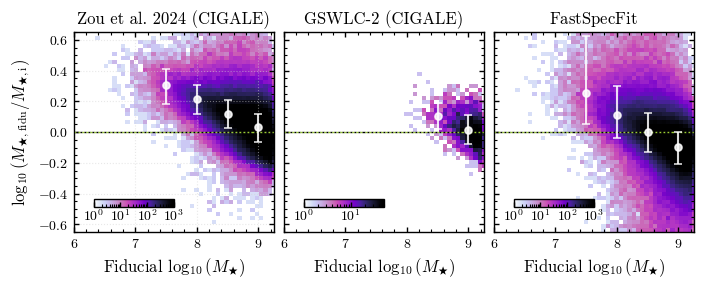

In [174]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

ax = make_subplots(
    ncol=3, nrow=1,
    row_spacing=[MARGIN_LABEL, MARGIN_PAD],
    col_spacing=[MARGIN_LABEL, MARGIN_SHARED, MARGIN_SHARED, MARGIN_PAD],
)

xmstar = "LOG_MSTAR_M24" 
ylim = 0.65

cmap = cmr.gothic_r.copy()
cmap.set_under(alpha=0.)

def add_corner_cbar(ax_parent, mappable):
    """Put a small horizontal colorbar in the bottom-left corner of ax_parent."""
    fig = ax_parent.figure
    
    # Get the TRUE position from the Divider locator
    renderer = fig.canvas.get_renderer()
    bbox = ax_parent.get_axes_locator()(ax_parent, renderer)
    
    x0, y0, w, h = 0.1, 0.125, 0.4, 0.04  # axes fraction
    
    cax = fig.add_axes([
        bbox.x0 + x0 * bbox.width,
        bbox.y0 + y0 * bbox.height,
        w * bbox.width,
        h * bbox.height,
    ])
    cbar = plt.colorbar(mappable, cax=cax, orientation="horizontal")
    cbar.ax.tick_params(pad=1)
    return cbar


# --- Panel 0: Zou et al. 2024 ---
ax_id = 0
ax[ax_id].set_title(r"Zou et al. 2024 (CIGALE)")
h, xedges, yedges, im = ax[ax_id].hist2d(
    main_hu_match[xmstar],
    main_hu_match[xmstar] - (np.log10(hu_match["MASS_CG"]) + 0.03),
    range=((6, 9.5), (-ylim, ylim)), bins=50,
    norm=LogNorm(vmin=1, vmax=1000), cmap=cmap, rasterized=True,
)
add_corner_cbar(ax[ax_id], im)

# --- Panel 1: GSWLC-2 ---
ax_id = 1
ax[ax_id].set_title(r"GSWLC-2 (CIGALE)")
h, xedges, yedges, im = ax[ax_id].hist2d(
    main_gswlc_match[xmstar],
    main_gswlc_match[xmstar] - (gswlc_match["LOGMSTAR"] + 0.03),
    range=((6, 9.5), (-ylim, ylim)), bins=50,
    norm=LogNorm(vmin=1, vmax=50), cmap=cmap, rasterized=True,
)
add_corner_cbar(ax[ax_id], im)

# --- Panel 2: Fastspecfit ---
hubble_val = 0.67
ax_id = 2
ax[ax_id].set_title(r"$\mathrm{FastSpecFit}$")
h, xedges, yedges, im = ax[ax_id].hist2d(
    main[xmstar],
    main[xmstar] - (fastspec["LOGMSTAR"] - 2 * np.log10(hubble_val)),
    range=((6, 9.5), (-ylim, ylim)), bins=50,
    norm=LogNorm(vmin=1, vmax=1000), cmap=cmap, rasterized=True,
)
add_corner_cbar(ax[ax_id], im)

# ... rest of your loop (axis limits, labels, error bars) unchanged ...

for i,axi in enumerate(ax):
    axi.set_xlim([6,9.25])
    axi.set_ylim([-ylim,ylim])
    
    axi.set_xlabel(r"Fiducial $\log_{10}(M_{\bigstar})$")
    ax[0].set_ylabel(r"$\log_{10}(M_{\bigstar, \rm fidu} / M_{\bigstar, \rm i})$")
    ax[0].grid(ls = ":",color = "lightgrey",alpha = 0.5)
    
    xgrid = np.linspace(6,9.25,100)
    make_alternating_plot(ax[i],xgrid,0*xgrid,dash_len=1,color_1="yellowgreen",color_2="k",lw=1)

    # --- binned median + 16/84 percentile error bars ---
    # Reconstruct the y-data for each panel
    if i == 0:
        xdata = main_hu_match[xmstar]
        ydata = main_hu_match[xmstar] - (np.log10(hu_match["MASS_CG"]) + 0.03)
    elif i == 1:
        xdata = main_gswlc_match[xmstar]
        ydata = main_gswlc_match[xmstar] - (gswlc_match["LOGMSTAR"] + 0.03)
    elif i == 2:
        xdata = main[xmstar]
        ydata = main[xmstar] - (fastspec["LOGMSTAR"] - 2 * np.log10(hubble_val))

    xdata = np.asarray(xdata)
    ydata = np.asarray(ydata)

    bin_width = 0.2
    for xcen in [7.5,8,8.5, 9]:
        mask = (xdata >= xcen - bin_width / 2) & (xdata < xcen + bin_width / 2)
        if mask.sum() > 100:
            med = np.median(ydata[mask])
            p16 = np.percentile(ydata[mask], 16)
            p84 = np.percentile(ydata[mask], 84)

            if i == 3:
                axi.errorbar(xcen, med,
                             yerr=[[med - p16], [p84 - med]],
                             fmt='none', color='white',
                             ecolor='white', elinewidth=1.5, capsize=3, zorder=10, alpha=0.85)
            else:
                axi.errorbar(xcen, med,
                             yerr=[[med - p16], [p84 - med]],
                             fmt='o', color='white', markeredgecolor='white',
                             markeredgewidth=1.2, markersize=5, alpha=0.85,
                             ecolor='white', elinewidth=1.5, capsize=3, zorder=10)

    if i != 0:
        axi.set_yticklabels([])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/stellar_mass_comp.pdf")

plt.show()



In [58]:
2*np.log10(hubble_val)

-0.34785039459834705

## Make a plot of the median difference between fiducial and various photometric stellar mass estimates!!

In [177]:
from desi_lowz_funcs import get_stellar_mass_mia
from desi_lowz_funcs import get_stellar_mass



In [178]:
fastspec[:2]

TARGETID,RA,DEC,SNR_B,SNR_R,SNR_Z,APERCORR,APERCORR_G,APERCORR_R,APERCORR_Z,OII_3726_FLUX,OII_3726_FLUX_IVAR,OII_3729_FLUX,OII_3729_FLUX_IVAR,OIII_4363_FLUX,OIII_4363_FLUX_IVAR,HEII_4686_FLUX,HEII_4686_FLUX_IVAR,HBETA_FLUX,HBETA_FLUX_IVAR,OIII_4959_FLUX,OIII_4959_FLUX_IVAR,OIII_5007_FLUX,OIII_5007_FLUX_IVAR,HEI_5876_FLUX,HEI_5876_FLUX_IVAR,NII_6548_FLUX,NII_6548_FLUX_IVAR,HALPHA_FLUX,HALPHA_FLUX_IVAR,HALPHA_BROAD_FLUX,HALPHA_BROAD_FLUX_IVAR,NII_6584_FLUX,NII_6584_FLUX_IVAR,SII_6716_FLUX,SII_6716_FLUX_IVAR,SII_6731_FLUX,SII_6731_FLUX_IVAR,SIII_9069_FLUX,SIII_9069_FLUX_IVAR,SIII_9532_FLUX,SIII_9532_FLUX_IVAR,HALPHA_BOXFLUX,HALPHA_BOXFLUX_IVAR,HALPHA_EW,HALPHA_EW_IVAR,DN4000,DN4000_OBS,DN4000_IVAR,DN4000_MODEL,VDISP,VDISP_IVAR,LOGMSTAR,MAG_G_FIBER_NOEMI,MAG_R_FIBER_NOEMI,MAG_G_FIBER_NOEMI_ERR,MAG_R_FIBER_NOEMI_ERR,MAG_G_DECAM_MODEL_NOEMI,MAG_R_DECAM_MODEL_NOEMI,MAG_G_DECAM_MODEL_WEMI,MAG_R_DECAM_MODEL_WEMI,MAG_G_BASS_MODEL_WEMI,MAG_R_BASS_MODEL_WEMI,MAG_G_SDSS_MODEL_NOEMI,MAG_R_SDSS_MODEL_NOEMI,MAG_G_SDSS_Z0_MODEL_NOEMI,MAG_R_SDSS_Z0_MODEL_NOEMI,DELTA_MAG_G_BASS2DECAM,DELTA_MAG_R_BASS2DECAM,DELTA_MAG_G_NEB,DELTA_MAG_R_NEB,DELTA_MAG_G_DECAM2SDSS,DELTA_MAG_R_DECAM2SDSS,DELTA_MAG_G_KCORR,DELTA_MAG_R_KCORR,LOG_SFR_HALPHA,LOG_SFR_HALPHA_ERR,LOG_MSTAR_24_FIBER,LOG_HALPHA_SFR_FIBER,Z_GAS_R23_N2
int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64
39627066986994125,58.82791003142589,-31.167992883134954,0.7362137,1.4110432,1.4763778,17.617802,16.742657,18.288889,17.617802,0.13864987,0.0036776955,1.2419373,0.003478581,0.0038752842,0.04712536,8.606093,0.10930019,3.6840034,0.12549414,2.1664715,0.12482052,6.525919,0.13526016,5.365553,0.25182992,1.139345,0.45386365,13.020986,0.5125305,0.0,0.0,3.3743422,0.46464396,6.9175406,0.40019593,4.389449,0.42514646,3.668044,0.1432467,0.0,0.0,11.785126,0.31097978,16.42255,0.17391735,0.6386112,0.5914388,21.08646,1.2983865,125.0,0.0,8.49248,21.43277905623485,21.14485215847107,0.03289679464639537,0.021915955150509044,21.322842018221912,21.163405013953138,21.302226286983696,21.129652091908632,21.311635537978574,21.128731131004766,21.371494434650785,21.181155038507427,21.34586892648177,21.192801301628606,-0.0,0.0,0.02061573123821603,0.033752922044506306,0.048652416428872414,0.017750024554288757,-0.02562550816901421,0.01164626312117889,-1.3582861284908159,0.06401520193870712,7.462507,-2.871629063169072,--
39627066995376721,59.235244922847556,-31.360982247692228,1.1808858,2.8670604,3.0106993,3.754026,3.3544269,3.754026,3.7849154,11.179523,0.008950349,16.883858,0.009275746,0.0,0.0,3.7785964,0.1884629,8.962078,0.21007247,3.5595784,0.20890892,10.710385,0.20822038,0.015966449,0.74877626,2.0687923,1.2339053,27.447546,0.602077,0.0,0.0,6.107305,1.3206978,5.002391,1.1459689,5.41488,1.2282068,1.2406223,1.0048556,0.0,0.0,27.825468,0.2770433,13.607072,1.4806414,1.5176805,1.3350921,9.755537,1.3523571,156.99861,8.72752e-05,8.935404,20.641814063556886,20.237798478084805,0.0219118061815352,0.010540002590324369,20.58991423240165,20.22444045712625,20.57672636767999,20.209394306012342,20.586093790910418,20.210996925341107,20.628981422299205,20.27585549931249,20.598057943228373,20.262580033212544,-0.0,-0.0,0.013187864721661668,0.015046151113907058,0.039067189897554755,0.05141504218624249,-0.03092347907083237,-0.013275466099948119,-1.1516737705648576,0.026566448148327832,8.56195,-1.8976532064409344,--


In [181]:
mag_g_corr = main["MAG_G"].data + fastspec["DELTA_MAG_G_BASS2DECAM"].data + fastspec["DELTA_MAG_G_DECAM2SDSS"].data +  fastspec["DELTA_MAG_G_KCORR"].data +  fastspec["DELTA_MAG_G_NEB"].data 
mag_r_corr = main["MAG_R"].data + fastspec["DELTA_MAG_R_BASS2DECAM"].data + fastspec["DELTA_MAG_R_DECAM2SDSS"].data +  fastspec["DELTA_MAG_R_KCORR"].data +  fastspec["DELTA_MAG_R_NEB"].data 


In [182]:
from desi_lowz_funcs import get_stellar_mass_bell03

In [183]:
##yes nebular correction but everything else is the same!!
mstar_mia_YES_CORR = get_stellar_mass_mia(mag_g_corr - mag_r_corr,
                    mag_g_corr,
                    0 * main["Z_CMB"].data,
                    d_in_mpc = main["LUMI_DIST_MPC"],
                    input_zred=False,)

mstar_saga_YES_CORR = get_stellar_mass(mag_g_corr - mag_r_corr,
                    mag_r_corr,
                    0 * main["Z_CMB"].data,
                    d_in_mpc = main["LUMI_DIST_MPC"],input_zred=False)

###

mstar_bell03 = get_stellar_mass_bell03( mag_g_corr - mag_r_corr,
                        mag_r_corr,
                        0 * main["Z_CMB"].data,
                        d_in_mpc=main["LUMI_DIST_MPC"],
                        input_zred=False )

def get_median_relation(mstar_org, mstar_comp):
    xdata= mstar_org
    ydata = mstar_org - mstar_comp
    
    bin_width=0.15
    bin_cens = np.arange(6,9.25,bin_width)
    meds = []
    for xcen in bin_cens:
        mask = (xdata >= xcen - bin_width / 2) & (xdata < xcen + bin_width / 2)
        if np.sum(mask) > 5:
            med = np.median(ydata[mask])
            meds.append( med)
        else:
            meds.append(np.nan)

    return bin_cens, meds

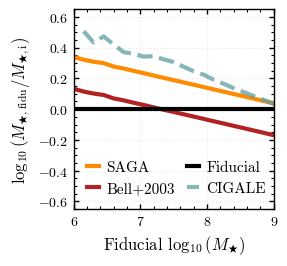

In [192]:
fig,ax = make_subplots(1,1,return_fig=True)


lw = 3

#######

bin_cens, mia_comp = get_median_relation(main["LOG_MSTAR_M24"].data, mstar_mia_YES_CORR)
bin_cens, saga_comp = get_median_relation(main["LOG_MSTAR_M24"].data, mstar_saga_YES_CORR)

bin_cens, bell03_comp = get_median_relation(main["LOG_MSTAR_M24"].data, mstar_bell03)

bin_cens, cigale_comp = get_median_relation(main_hu_match["LOG_MSTAR_M24"], np.log10(hu_match["MASS_CG"]) + 0.03)

#######c


ax[0].plot(bin_cens, saga_comp,lw=lw, label = r"SAGA",color="darkorange")

ax[0].plot(bin_cens, bell03_comp,lw=lw,color="firebrick", label = "Bell+2003")

ax[0].plot(bin_cens, mia_comp,lw=lw,color="k", label = "Fiducial")

ax[0].plot(bin_cens, cigale_comp,lw=lw,label=r"CIGALE",color="cadetblue",ls="--",alpha=0.75)


###

ax[0].legend(frameon=False,loc="lower left",handlelength=0.75,handletextpad=0.5,ncol=2, columnspacing=0.8)
ax[0].set_xlim([6,9])
ax[0].set_ylim([-0.65,0.65])

ax[0].set_xlabel(r"Fiducial $\log_{10}(M_{\bigstar})$")
ax[0].set_ylabel(r"$\log_{10}(M_{\bigstar, \rm fidu} / M_{\bigstar, \rm i})$")
ax[0].grid(ls = ":",color = "lightgrey",alpha = 0.5)
    
xgrid = np.linspace(6,9.25,100)
# make_alternating_plot(ax[0],xgrid,0*xgrid,dash_len=1,color_1="yellowgreen",color_2="k",lw=1)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/stellar_mass_comp_methods.pdf")

plt.show()

## Compare some of the dwarfs in our catalog with objects from Spitzer Local Volume sample!

In [17]:
# from astropy.table import Table
# from astropy.coordinates import SkyCoord
# import astropy.units as u

# # Read the fixed-width file using the byte positions from the readme
# from astropy.io import ascii

# col_starts = [0, 15, 18, 21, 27, 28, 31, 34, 39, 45, 48, 52, 57, 59, 66, 72, 74]
# col_ends   = [13, 16, 19, 25, 27, 29, 32, 37, 43, 46, 50, 55, 57, 64, 70, 72, 78]
# col_names  = ['Name', 'RAh', 'RAm', 'RAs', 'DE_sign', 'DEd', 'DEm', 'DEs',
#               'Dist', 'TT', 'Ab_O', 'e_Ab_O', 'r_Ab_O', 'Meth', 'AFUV', 'r_AFUV', 'logMstar']

# spitzer_lvl_cat = ascii.read(
#     '/pscratch/sd/v/virajvm/catalog/spitzer_lvl_catalog.dat',
#     format='fixed_width_no_header',
#     col_starts=col_starts,
#     col_ends=col_ends,
#     names=col_names,
#     fill_values=[('---', '')],
# )

# # Build coordinate strings and parse with SkyCoord
# ra_strings = [f"{h} {m} {s}" for h, m, s in zip(spitzer_lvl_cat['RAh'], spitzer_lvl_cat['RAm'], spitzer_lvl_cat['RAs'])]
# dec_strings = [f"{sign}{d} {m} {s}" for sign, d, m, s in zip(spitzer_lvl_cat['DE_sign'], spitzer_lvl_cat['DEd'], spitzer_lvl_cat['DEm'], spitzer_lvl_cat['DEs'])]

# coords = SkyCoord(ra_strings, dec_strings, unit=(u.hourangle, u.deg))

# # Add RA, Dec in degrees to the table
# spitzer_lvl_cat['RA_deg'] = coords.ra.deg
# spitzer_lvl_cat['Dec_deg'] = coords.dec.deg

# vals = []
# for x in spitzer_lvl_cat['logMstar']:
#     try:
#         vals.append(float(x))
#     except (ValueError, TypeError):
#         vals.append(99.0)
# spitzer_lvl_cat['logMstar'] = vals

# # Print the columns of interest
# print(spitzer_lvl_cat['Name', 'RA_deg', 'Dec_deg', 'logMstar'][:4])

## PLOT: Impact of fiber based stellar mass and star formation rate!

In [61]:
main_all[:2]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,LOG_MSTAR_M24_ERR,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MSTAR_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,ASSOCIATED_TARGETIDS,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,DIST_SOURCE,PROPERTY_SOURCE_TARGETID
int64,bytes7,bytes6,int32,float64,float64,int32,float64,float64,float64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes10,int32,int32,bytes13,bool,float64,float64[2],bool,object,int64,bool,bytes10,int64
39627066986994125,sv1,bright,34722,0.032918604316881296,98.85089745232835,0,0.03264401958193863,58.82791003142589,-31.167992883134954,58.82791003142589,-31.167992883134954,DESI J058.8279-31.1679,148.21792602539062,8.843826293945312,0.04251172982109555,18.319110870361328,17.939651489257812,17.730533599853516,18.319110870361328,17.939651489257812,17.730533599853516,BGS_BRIGHT,0,0,TRACTOR_OG,False,7.116967678070068,0.6592394709587097 .. -87.19556427001953,False,[39627066986994125],39627066986994125,True,V_CMB,39627066986994125
39627066995376721,sv1,bright,34721,0.06713081686670527,444.1444324851036,0,0.06685584372174991,59.235244922847556,-31.360982247692228,59.235244922847556,-31.360982247692228,DESI J059.2352-31.3609,311.04266357421875,9.242656707763672,0.02500834480091534,19.275266647338867,18.767732620239258,18.4816951751709,19.275266647338867,18.767732620239258,18.4816951751709,BGS_BRIGHT,0,0,TRACTOR_OG,False,1.832580804824829,0.9732345342636108 .. -16.84249496459961,False,[39627066995376721],39627066995376721,True,V_CMB,39627066995376721


In [62]:
fib_based_all[:2]

NameError: name 'fib_based_all' is not defined

In [53]:
main_all[:2]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,LOG_MSTAR_M24_ERR,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MSTAR_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,ASSOCIATED_TARGETIDS,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,DIST_SOURCE,PROPERTY_SOURCE_TARGETID
int64,bytes7,bytes6,int32,float64,float64,bool,float64,float64,float64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes10,int64,int32,bytes13,bool,float64,float64[2],bool,object,int64,bool,bytes10,int64
39627066986994125,sv1,bright,34722,0.032918604316881296,98.85089745232835,False,0.03264401958193863,58.82791003142589,-31.167992883134954,58.82791003142589,-31.167992883134954,DESI J058.8279-31.1679,148.21792602539062,8.843826293945312,0.04251172982109555,18.319110870361328,17.939651489257812,17.730533599853516,18.319110870361328,17.939651489257812,17.730533599853516,BGS_BRIGHT,0,0,TRACTOR_OG,False,7.116967678070068,0.6592394709587097 .. -87.19556427001953,False,[39627066986994125],39627066986994125,True,V_CMB,39627066986994125
39627066995376721,sv1,bright,34721,0.06713081686670527,444.1444324851036,False,0.06685584372174991,59.235244922847556,-31.360982247692228,59.235244922847556,-31.360982247692228,DESI J059.2352-31.3609,311.04266357421875,9.242656707763672,0.02500834480091534,19.275266647338867,18.767732620239258,18.4816951751709,19.275266647338867,18.767732620239258,18.4816951751709,BGS_BRIGHT,0,0,TRACTOR_OG,False,1.832580804824829,0.9732345342636108 .. -16.84249496459961,False,[39627066995376721],39627066995376721,True,V_CMB,39627066995376721


In [8]:
fastspec_all[:3]

TARGETID,RA,DEC,SNR_B,SNR_R,SNR_Z,APERCORR,APERCORR_G,APERCORR_R,APERCORR_Z,OII_3726_FLUX,OII_3726_FLUX_IVAR,OII_3729_FLUX,OII_3729_FLUX_IVAR,OIII_4363_FLUX,OIII_4363_FLUX_IVAR,HEII_4686_FLUX,HEII_4686_FLUX_IVAR,HBETA_FLUX,HBETA_FLUX_IVAR,OIII_4959_FLUX,OIII_4959_FLUX_IVAR,OIII_5007_FLUX,OIII_5007_FLUX_IVAR,HEI_5876_FLUX,HEI_5876_FLUX_IVAR,NII_6548_FLUX,NII_6548_FLUX_IVAR,HALPHA_FLUX,HALPHA_FLUX_IVAR,HALPHA_BROAD_FLUX,HALPHA_BROAD_FLUX_IVAR,NII_6584_FLUX,NII_6584_FLUX_IVAR,SII_6716_FLUX,SII_6716_FLUX_IVAR,SII_6731_FLUX,SII_6731_FLUX_IVAR,SIII_9069_FLUX,SIII_9069_FLUX_IVAR,SIII_9532_FLUX,SIII_9532_FLUX_IVAR,HALPHA_BOXFLUX,HALPHA_BOXFLUX_IVAR,HALPHA_EW,HALPHA_EW_IVAR,DN4000,DN4000_OBS,DN4000_IVAR,DN4000_MODEL,VDISP,VDISP_IVAR,LOGMSTAR,MAG_G_FIBER_NOEMI,MAG_R_FIBER_NOEMI,MAG_G_FIBER_NOEMI_ERR,MAG_R_FIBER_NOEMI_ERR,MAG_G_DECAM_MODEL_NOEMI,MAG_R_DECAM_MODEL_NOEMI,MAG_G_DECAM_MODEL_WEMI,MAG_R_DECAM_MODEL_WEMI,MAG_G_BASS_MODEL_WEMI,MAG_R_BASS_MODEL_WEMI,MAG_G_SDSS_MODEL_NOEMI,MAG_R_SDSS_MODEL_NOEMI,MAG_G_SDSS_Z0_MODEL_NOEMI,MAG_R_SDSS_Z0_MODEL_NOEMI,DELTA_MAG_G_BASS2DECAM,DELTA_MAG_R_BASS2DECAM,DELTA_MAG_G_NEB,DELTA_MAG_R_NEB,DELTA_MAG_G_DECAM2SDSS,DELTA_MAG_R_DECAM2SDSS,DELTA_MAG_G_KCORR,DELTA_MAG_R_KCORR,LOG_SFR_HALPHA,LOG_SFR_HALPHA_ERR,LOG_MSTAR_24_FIBER,LOG_HALPHA_SFR_FIBER,Z_GAS_R23_N2
int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64
39627066986994125,58.82791003142589,-31.167992883134954,0.7362137,1.4110432,1.4763778,17.617802,16.742657,18.288889,17.617802,0.13864987,0.0036776955,1.2419373,0.003478581,0.0038752842,0.04712536,8.606093,0.10930019,3.6840034,0.12549414,2.1664715,0.12482052,6.525919,0.13526016,5.365553,0.25182992,1.139345,0.45386365,13.020986,0.5125305,0.0,0.0,3.3743422,0.46464396,6.9175406,0.40019593,4.389449,0.42514646,3.668044,0.1432467,0.0,0.0,11.785126,0.31097978,16.42255,0.17391735,0.6386112,0.5914388,21.08646,1.2983865,125.0,0.0,8.49248,21.43277905623485,21.14485215847107,0.03289679464639537,0.021915955150509044,21.322842018221912,21.163405013953138,21.302226286983696,21.129652091908632,21.311635537978574,21.128731131004766,21.371494434650785,21.181155038507427,21.34586892648177,21.192801301628606,-0.0,0.0,0.02061573123821603,0.033752922044506306,0.048652416428872414,0.017750024554288757,-0.02562550816901421,0.01164626312117889,-1.3582861284908159,0.06401520193870712,7.462507,-2.871629063169072,--
39627066995376721,59.235244922847556,-31.360982247692228,1.1808858,2.8670604,3.0106993,3.754026,3.3544269,3.754026,3.7849154,11.179523,0.008950349,16.883858,0.009275746,0.0,0.0,3.7785964,0.1884629,8.962078,0.21007247,3.5595784,0.20890892,10.710385,0.20822038,0.015966449,0.74877626,2.0687923,1.2339053,27.447546,0.602077,0.0,0.0,6.107305,1.3206978,5.002391,1.1459689,5.41488,1.2282068,1.2406223,1.0048556,0.0,0.0,27.825468,0.2770433,13.607072,1.4806414,1.5176805,1.3350921,9.755537,1.3523571,156.99861,8.72752e-05,8.935404,20.641814063556886,20.237798478084805,0.0219118061815352,0.010540002590324369,20.58991423240165,20.22444045712625,20.57672636767999,20.209394306012342,20.586093790910418,20.210996925341107,20.628981422299205,20.27585549931249,20.598057943228373,20.262580033212544,-0.0,-0.0,0.013187864721661668,0.015046151113907058,0.039067189897554755,0.05141504218624249,-0.03092347907083237,-0.013275466099948119,-1.1516737705648576,0.026566448148327832,8.56195,-1.8976532064409344,--
39627067007963313,60.226366678070214,-31.212205289954937,1

In [9]:
# =============================================================================
# Stellar mass & sSFR: compare associates against the primary-catalog reference
#   - mstar diffs are computed from fiber-based photometric corrections only
#     (nebular, BASS->DECAM, DECAM->SDSS, k-correction), isolating fiber-specific
#     correction effects from raw photometric scatter between sources.
#     Reference = property source (whose mstar we adopt). TRACTOR_OG cut dropped.
#   - sSFR reference = primary fiber -> exclude TARGETID
# =============================================================================

all_base_mask = (main_all["DWARF_MASKBIT"] == 0) & (main_all["MSTAR_MASKBIT"] == 0)
assoc_base_mask = (fib_based_all["DWARF_MASKBIT"] == 0) & (fib_based_all["MSTAR_MASKBIT"] == 0)

prim_mask = all_base_mask & (main_all["DWARF_PRIMARY"] == 1)

main_prim = main_all[prim_mask]
spec_derived_prim = fastspec_all[prim_mask]

main_assoc = fib_based_all[assoc_base_mask]
spec_derived_assoc = fastspec_all[assoc_base_mask]
assoc_tgids = main_assoc["TARGETID"].data

# --- Precompute total g/r mag corrections per fiber ---
# Total correction = sum of (BASS2DECAM, nebular, DECAM2SDSS, k-correction)
DELTA_G_COLS = ["DELTA_MAG_G_BASS2DECAM", "DELTA_MAG_G_NEB",
                "DELTA_MAG_G_DECAM2SDSS", "DELTA_MAG_G_KCORR"]
DELTA_R_COLS = ["DELTA_MAG_R_BASS2DECAM", "DELTA_MAG_R_NEB",
                "DELTA_MAG_R_DECAM2SDSS", "DELTA_MAG_R_KCORR"]

def total_delta(tbl, cols):
    return np.sum([np.asarray(tbl[c]) for c in cols], axis=0)

# log_mstar correction shift = 0.950*delta_g - 1.315*delta_r
# (derived from log_mstar = const(d) + 0.950*g - 1.315*r)
G_COEF, R_COEF = 0.950, -1.315

prim_mstar_corr = (G_COEF * total_delta(spec_derived_prim, DELTA_G_COLS)
                   + R_COEF * total_delta(spec_derived_prim, DELTA_R_COLS))
assoc_mstar_corr = (G_COEF * total_delta(spec_derived_assoc, DELTA_G_COLS)
                    + R_COEF * total_delta(spec_derived_assoc, DELTA_R_COLS))

# Precompute sSFR finite-ness on both prim and assoc sides
prim_ssfr_all = (np.asarray(spec_derived_prim["LOG_HALPHA_SFR_FIBER"])
                 - np.asarray(spec_derived_prim["LOG_MSTAR_24_FIBER"]))
prim_ssfr_finite = np.isfinite(prim_ssfr_all)

assoc_ssfr_all = (np.asarray(spec_derived_assoc["LOG_HALPHA_SFR_FIBER"])
                  - np.asarray(spec_derived_assoc["LOG_MSTAR_24_FIBER"]))
assoc_ssfr_finite = np.isfinite(assoc_ssfr_all)

# We need to locate the property-source row within main_assoc to get its
# correction value. Build a tgid -> index lookup once.
assoc_tgid_to_idx = {tid: j for j, tid in enumerate(assoc_tgids)}

zreds_ms, tgids_ms, mstar_diffs = [], [], []
zreds_sfr, tgids_sfr, sSFR_diffs = [], [], []

for i in trange(len(main_prim)):
    assoc_ids = main_prim["ASSOCIATED_TARGETIDS"][i]
    if len(assoc_ids) <= 1:
        continue

    prop_tgid = main_prim["PROPERTY_SOURCE_TARGETID"][i]
    prim_tgid = main_prim["TARGETID"][i]

    # --- Stellar mass: correction-only diffs, reference = property source ---
    # The property source's correction value lives in spec_derived_assoc, so
    # look it up there. (The primary row i in spec_derived_prim is a different
    # fiber in general.)
    prop_idx = assoc_tgid_to_idx.get(prop_tgid, None)

    if prop_idx is not None:
        ids_no_prop = assoc_ids[assoc_ids != prop_tgid]
        mask_ms = np.isin(assoc_tgids, ids_no_prop)

        if mask_ms.any():
            prop_corr_i = assoc_mstar_corr[prop_idx]
            assoc_corr_i = assoc_mstar_corr[mask_ms]

            finite = np.isfinite(assoc_corr_i)
            assoc_corr_i = assoc_corr_i[finite]

            if np.isfinite(prop_corr_i) and len(assoc_corr_i) > 0:
                n = len(assoc_corr_i)
                zreds_ms.append(np.full(n, float(main_prim["Z"][i])))
                tgids_ms.append(np.full(n, prim_tgid))
                mstar_diffs.append(assoc_corr_i - prop_corr_i)

    # --- sSFR: exclude primary fiber, require finite SFR on both sides ---
    if not prim_ssfr_finite[i]:
        continue

    ids_no_prim = assoc_ids[assoc_ids != prim_tgid]
    mask_sfr = np.isin(assoc_tgids, ids_no_prim) & assoc_ssfr_finite

    if mask_sfr.any():
        spec_i = spec_derived_assoc[mask_sfr]

        primary_ssfr = prim_ssfr_all[i]
        ssfr_vals = (spec_i["LOG_HALPHA_SFR_FIBER"].data
                     - spec_i["LOG_MSTAR_24_FIBER"].data)

        n = len(ssfr_vals)
        zreds_sfr.append(np.full(n, float(main_prim["Z"][i])))
        tgids_sfr.append(np.full(n, prim_tgid))
        sSFR_diffs.append(ssfr_vals - primary_ssfr)

# Flatten
zreds_ms = np.concatenate(zreds_ms) if zreds_ms else np.array([])
tgids_ms = np.concatenate(tgids_ms) if tgids_ms else np.array([])
mstar_diffs = np.concatenate(mstar_diffs) if mstar_diffs else np.array([])

zreds_sfr = np.concatenate(zreds_sfr) if zreds_sfr else np.array([])
tgids_sfr = np.concatenate(tgids_sfr) if tgids_sfr else np.array([])
sSFR_diffs = np.concatenate(sSFR_diffs) if sSFR_diffs else np.array([])


# =============================================================================
# Metallicity: reference = primary fiber -> exclude TARGETID
# =============================================================================

zmet_valid = ~np.isnan(np.asarray(fastspec_all["Z_GAS_R23_N2"]))

zmet_prim_mask = ((main_all["DWARF_PRIMARY"] == 1)
                  & (main_all["DWARF_MASKBIT"] == 0)
                  & zmet_valid)
zmet_assoc_mask = (fib_based_all["DWARF_MASKBIT"] == 0) & zmet_valid

main_zmet_prim = main_all[zmet_prim_mask]
spec_zmet_prim = fastspec_all[zmet_prim_mask]
spec_zmet_assoc = fastspec_all[zmet_assoc_mask]
zmet_assoc_tgids = spec_zmet_assoc["TARGETID"].data

zreds_zmet, tgids_zmet, zmet_diffs = [], [], []

for i in trange(len(main_zmet_prim)):
    assoc_ids = main_zmet_prim["ASSOCIATED_TARGETIDS"][i]
    if len(assoc_ids) <= 1:
        continue

    prim_tgid = main_zmet_prim["TARGETID"][i]
    ids_no_prim = assoc_ids[assoc_ids != prim_tgid]

    mask = np.isin(zmet_assoc_tgids, ids_no_prim)
    if not mask.any():
        continue

    spec_i = spec_zmet_assoc[mask]
    if len(spec_i) == 0:
        continue

    primary_zmet = spec_zmet_prim["Z_GAS_R23_N2"][i]
    zmet_vals = spec_i["Z_GAS_R23_N2"].data

    n = len(zmet_vals)
    zreds_zmet.append(np.full(n, float(main_zmet_prim["Z"][i])))
    tgids_zmet.append(np.full(n, prim_tgid))
    zmet_diffs.append(zmet_vals - primary_zmet)

zreds_zmet = np.concatenate(zreds_zmet) if zreds_zmet else np.array([])
tgids_zmet = np.concatenate(tgids_zmet) if tgids_zmet else np.array([])
zmet_diffs = np.concatenate(zmet_diffs) if zmet_diffs else np.array([])

100%|██████████| 155725/155725 [00:12<00:00, 12295.71it/s]


In [63]:
def get_regions(xdata,ydata, bin_cens, bin_width):
    all_meds = []
    all_p16 = []
    all_p84 = []
    all_cens = []
    
    for xcen in bin_cens:
        mask = (xdata >= xcen - bin_width / 2) & (xdata < xcen + bin_width / 2)
        if mask.sum() > 10:
            med = np.median(ydata[mask])
            p16 = np.percentile(ydata[mask], 16)
            p84 = np.percentile(ydata[mask], 84)
            
            all_meds.append(med)
            all_p16.append(p16)
            all_p84.append(p84)
            all_cens.append(xcen)
        
    return all_cens, np.array(all_meds), np.array(all_p16), np.array(all_p84)
    
            # if i == 3:
            #     axi.errorbar(xcen, med,
            #                  yerr=[[med - p16], [p84 - med]],
            #                  fmt='none', color='white',
            #                  ecolor='white', elinewidth=1.5, capsize=3, zorder=10, alpha=0.85)
            # else:
            #     axi.errorbar(xcen, med,
            #                  yerr=[[med - p16], [p84 - med]],
            #                  fmt='o', color='white', markeredgecolor='white',
            #                  markeredgewidth=1.2, markersize=5, alpha=0.85,
            #                  ecolor='white', elinewidth=1.5, capsize=3, zorder=10)

In [64]:
from desi_lowz_funcs import get_contours

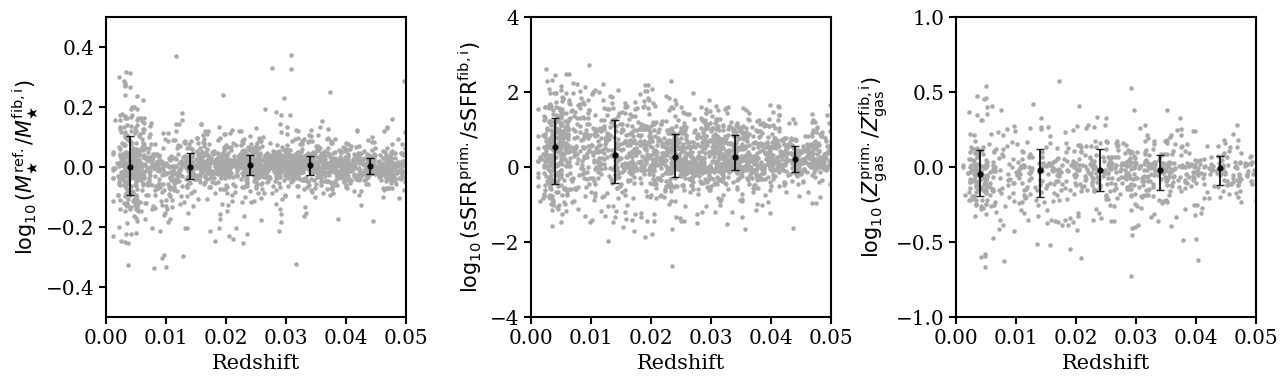

In [98]:
fig,ax = make_subplots(3,1,return_fig=True,col_spacing=1.25)

color="darkgrey"
pts_size = 5
zbins = np.array([0.004, 0.014, 0.024, 0.034, 0.044])
bin_size=0.004

ax[0].scatter( zreds_ms, mstar_diffs,s=pts_size,marker="o",color=color)

zcens_ms, ms_meds, ms_16, ms_84 = get_regions(zreds_ms, np.array(mstar_diffs), zbins , bin_size)

ax[0].errorbar(zcens_ms, ms_meds,
             yerr=np.array([ms_meds - ms_16, ms_84 - ms_meds]),
             fmt='o', color='k',markersize=3.5,
             ecolor='k', elinewidth=1.5, capsize=3, zorder=10, alpha=0.85)
             
ax[0].set_ylim([-0.5,0.5])

ax[0].set_ylabel(r"$\log_{10} (M_{\bigstar}^{\rm ref.} / M_{\bigstar}^{\rm fib,i})$",fontsize=15)

###################


ax[1].scatter( zreds_sfr, sSFR_diffs,s=pts_size,marker="o",color=color)
ax[1].set_ylabel(r"$\log_{10} (\text{sSFR}^{\rm prim.} / \text{sSFR}^{\rm fib,i})$",fontsize=15)
ax[1].set_ylim([-4,4])

zcens_sfr, sfr_meds, sfr_16, sfr_84 = get_regions(zreds_sfr, np.array(sSFR_diffs), zbins , bin_size)

ax[1].errorbar(zcens_sfr, sfr_meds,
             yerr=np.array([sfr_meds - sfr_16, sfr_84 - sfr_meds]),
             fmt='o', color='k',markersize=3.5,
             ecolor='k', elinewidth=1.5, capsize=3, zorder=10, alpha=0.85)

###################


ax[2].scatter( zreds_zmet, zmet_diffs,s=pts_size,marker="o",color=color)
ax[2].set_ylabel(r"$\log_{10} (Z_{\rm gas}^{\rm prim.} / Z_{\rm gas}^{\rm fib,i})$",fontsize=15)
ax[2].set_ylim([-1,1])

zcens_zmet, zmet_meds, zmet_16, zmet_84 = get_regions(zreds_zmet, np.array(zmet_diffs), zbins , bin_size)

ax[2].errorbar(zcens_zmet, zmet_meds,
             yerr=np.array([zmet_meds - zmet_16, zmet_84 - zmet_meds]),
             fmt='o', color='k',markersize=3.5,
             ecolor='k', elinewidth=1.5, capsize=3, zorder=10, alpha=0.85)

###################

for axi in ax:
    axi.set_xlim([0,0.05])
    axi.set_xlabel("Redshift",fontsize=15)
    axi.set_xticks([0,0.01,0.02,0.03,0.04,0.05])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/fiber_based_effects.pdf",bbox_inches="tight")

plt.show()


what are those extreme outlier points at zred ~ 0.03 or something ... suspicious

In [32]:
## sometimes some of the large diffrences are because objects are overmerged --- 

In [33]:
tgid_con[ np.abs(delt_mstar_con) > 0.4]

#some of the large differences are because of shreds being correctly handled now!
#can make a note of this pin the aper.


array([39627787182540222, 39633203748668189,  2715147344805889,
       39627726520323672, 39627751577095177, 39627751577095177,
       39627790219220294, 39627878198938674, 39627896603545910,
       39627992825069945, 39628112417261210, 39628125507686730,
       39628502567229604, 39633145640784829, 39627793868261635,
       39627872498877595, 39627896637096350, 39627896637096350])

In [182]:
temp = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_BGS_BRIGHT_shreds_catalog_w_aper_mags.fits")


In [184]:
temp[temp["TARGETID"] == 39627468348330752 ]

TARGETID,SURVEY,PROGRAM,HEALPIX,SPGRPVAL,Z,ZERR,ZWARN,CHI2,COEFF,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,COADD_FIBERSTATUS,RA,DEC,PMRA,PMDEC,REF_EPOCH,FA_TARGET,FA_TYPE,OBJTYPE,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKNAME,BRICKID,BRICK_OBJID,MORPHTYPE,EBV,FIBERFLUX_R,MASKBITS,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV1_SCND_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV2_SCND_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV3_SCND_TARGET,PLATE_RA,PLATE_DEC,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,MEAN_FIBER_RA,STD_FIBER_RA,MEAN_FIBER_DEC,STD_FIBER_DEC,MIN_MJD,MAX_MJD,MEAN_MJD,TSNR2_GPBDARK_B,TSNR2_ELG_B,TSNR2_GPBBRIGHT_B,TSNR2_LYA_B,TSNR2_BGS_B,TSNR2_GPBBACKUP_B,TSNR2_QSO_B,TSNR2_LRG_B,TSNR2_GPBDARK_R,TSNR2_ELG_R,TSNR2_GPBBRIGHT_R,TSNR2_LYA_R,TSNR2_BGS_R,TSNR2_GPBBACKUP_R,TSNR2_QSO_R,TSNR2_LRG_R,TSNR2_GPBDARK_Z,TSNR2_ELG_Z,TSNR2_GPBBRIGHT_Z,TSNR2_LYA_Z,TSNR2_BGS_Z,TSNR2_GPBBACKUP_Z,TSNR2_QSO_Z,TSNR2_LRG_Z,TSNR2_GPBDARK,TSNR2_ELG,TSNR2_GPBBRIGHT,TSNR2_LYA,TSNR2_BGS,TSNR2_GPBBACKUP,TSNR2_QSO,TSNR2_LRG,MAIN_NSPEC,MAIN_PRIMARY,SV_NSPEC,SV_PRIMARY,ZCAT_NSPEC,ZCAT_PRIMARY,DESINAME,FLUX_G,FLUX_IVAR_G,MAG_G,MAG_G_ERR,FLUX_R,FLUX_IVAR_R,MAG_R,MAG_R_ERR,FLUX_Z,FLUX_IVAR_Z,MAG_Z,MAG_Z_ERR,FIBERMAG_R,OBJID,SIGMA_G,FRACFLUX_G,RCHISQ_G,SIGMA_GOOD_G,SIGMA_R,FRACFLUX_R,RCHISQ_R,SIGMA_GOOD_R,SIGMA_Z,FRACFLUX_Z,RCHISQ_Z,SIGMA_GOOD_Z,SHAPE_R,SHAPE_R_ERR,MU_R,MU_R_ERR,SERSIC,SERSIC_IVAR,BA,TYPE,PHI,NOBS_G,NOBS_R,NOBS_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,V_HELIO,V_GSR,V_CMB,Z_CMB,DIST_MPC_VCMB,DIST_MPC_FIDU,DIST_MPC_NAM,OTHER_DIST_MPC_NAM,LOGM_SAGA_VCMB,LOGM_SAGA_FIDU,LOGM_M24_VCMB,SWEEP,is_south,STARFDIST,STARDIST_DEG,STARMAG,STAR_RADIUS_ARCSEC,STAR_RA,STAR_DEC,GOOD_SIGMA,PHOTO_REPROCESS,IMAGE_SIZE_PIX,SAMPLE,SGA_ID_MATCH,SGA_D26_NORM_DIST,SGA_DIST_DEG,PCNN_FRAGMENT,IMAGE_PATH,FILE_PATH,NEAREST_STAR_NORM_DIST,NEAREST_STAR_MAX_MAG,APER_ORG_R3_MAG,APER_ORG_R3_NO_SUBTRACT_MAG,SAVE_PATH,APER_SOURCE_ON_ORG_BLOB,SAVE_SUMMARY_APER_PATH,APER_ORG_R3_FRAC_MASK_PIX,IMAGE_MASK_PIX_FRAC,COG_MAG_G_ISOLATE,COG_MAG_R_ISOLATE,COG_MAG_Z_ISOLATE,COG_MAG_G_NO_ISOLATE,COG_MAG_R_NO_ISOLATE,COG_MAG_Z_NO_ISOLATE,APER_R4_MAG_G_ISOLATE,APER_R4_MAG_R_ISOLATE,APER_R4_MAG_Z_ISOLATE,APER_R4_MAG_G_NO_ISOLATE,APER_R4_MAG_R_NO_ISOLATE,APER_R4_MAG_Z_NO_ISOLATE,TRACTOR_ONLY_MAG_G_ISOLATE,TRACTOR_ONLY_MAG_R_ISOLATE,TRACTOR_ONLY_MAG_Z_ISOLATE,TRACTOR_ONLY_MAG_G_NO_ISOLATE,TRACTOR_ONLY_MAG_R_NO_ISOLATE,TRACTOR_ONLY_MAG_Z_NO_ISOLATE,TRACTOR_BRIGHTEST_SOURCE_MAGS_ISOLATE,TRACTOR_BRIGHTEST_SOURCE_MAGS_NO_ISOLATE,SIMPLE_PHOTO_MAG_G,SIMPLE_PHOTO_MAG_R,SIMPLE_PHOTO_MAG_Z,COG_MAG_ERR_ISOLATE,FIBER_MAG_ISOLATE,COG_PARAMS_G_ISOLATE,COG_PARAMS_R_ISOLATE,COG_PARAMS_Z_ISOLATE,COG_PARAMS_G_ERR_ISOLATE,COG_PARAMS_R_ERR_ISOLATE,COG_PARAMS_Z_ERR_ISOLATE,APERFRAC_R4_IN_IMG_ISOLATE,COG_CHI2_ISOLATE,COG_DOF_ISOLATE,COG_DECREASE_MAX_LEN_ISOLATE,COG_DECREASE_MAX_MAG_ISOLATE,APER_PARAMS_ISOLATE,APER_CEN_RADEC_ISOLATE,APER_CEN_XY_PIX_ISOLATE,APER_R4_MASK_FRAC_ISOLATE,APER_CEN_MASKED_ISOLATE,APER_MU_R_SIZES_ISOLATE,COG_MAG_ERR_NO_ISOLATE,FIBER_MAG_NO_ISOLATE,COG_PARAMS_G_NO_ISOLATE,COG_PARAMS_R_NO_ISOLATE,COG_PARAMS_Z_NO_ISOLATE,COG_PARAMS_G_ERR_NO_ISOLATE,COG_PARAMS_R_ERR_NO_ISOLATE,COG_PARAMS_Z_ERR_NO_ISOLATE,APERFRAC_R4_IN_IMG_NO_ISOLATE,COG_CHI2_NO_ISOLATE,COG_DOF_NO_ISOLATE,COG_DECREASE_MAX_LEN_NO_ISOLATE,COG_DECREASE_MAX_MAG_NO_ISOLATE,APER_PARAMS_NO_ISOLATE,APER_CEN_RADEC_NO_ISOLATE,APER_CEN_XY_PIX_NO_ISOLATE,APER_R4_MASK_FRAC_NO_ISOLATE,APER_CEN_MASKED_NO_ISOLATE,APER_MU_R_SIZES_NO_ISOLATE,TRACTOR_ONLY_COG_MAG_ISOLATE,TRACTOR_ONLY_FIBER_MAG_ISOLATE,TRACTOR_ONLY_COG_MAG_ERR_ISOLATE,TRACTOR_ONLY_COG_PARAMS_G_ISOLATE,TRACTOR_ONLY_COG_PARAMS_G_ERR_ISOLATE,TRACTOR_ONLY_COG_PARAMS_R_ISOLATE,TRACTOR

In [196]:
from consolidate_photometry import consolidate_new_photo, consolidate_positions_and_shapes
from mass_and_photo_corrections import _apply_delta_mag_corrections

bgsb_shred = Table.read(f"/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_BGS_BRIGHT_shreds_catalog_w_aper_mags.fits")
bgsb_shred = consolidate_new_photo(bgsb_shred,sample="BGS_BRIGHT",flag_cog_nan_always=True)

Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.24410323753724936
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0030
MASKBIT=2^1, cog not converge, fraction: 0.062276
MASKBIT=2^2, bad resid, fraction : 0.0058
MASKBIT=2^3, cog curve decrease, fraction: 0.0101
MASKBIT=2^4, aperfrac-in image, fraction: 0.001111
MASKBIT=2^5, aperfrac-mask image, fraction: 0.050659
MASKBIT=2^6, image-frac mask, fraction: 0.000859
MASKBIT=2^7, bad colors, fraction: 0.000303
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.106420
MASKBIT=2^10, aper-cen masked, fraction: 0.052174
MASKBIT=2^11, no seg found, fraction: 0.000051
MASKBIT=2^12, near sga outskirts, fraction: 0.014597
Fraction of sources where org trac is likely good = 0.24410323753724936
Adding bit=0 for tractor_og type!
Updating the maskbits to reflect som

In [197]:
bgsb_shred[bgsb_shred["TARGETID"] == 39627468348330752 ]

TARGETID,SURVEY,PROGRAM,HEALPIX,SPGRPVAL,Z,ZERR,ZWARN,CHI2,COEFF,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,COADD_FIBERSTATUS,RA,DEC,PMRA,PMDEC,REF_EPOCH,FA_TARGET,FA_TYPE,OBJTYPE,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKNAME,BRICKID,BRICK_OBJID,MORPHTYPE,EBV,FIBERFLUX_R,MASKBITS,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV1_SCND_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV2_SCND_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV3_SCND_TARGET,PLATE_RA,PLATE_DEC,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,MEAN_FIBER_RA,STD_FIBER_RA,MEAN_FIBER_DEC,STD_FIBER_DEC,MIN_MJD,MAX_MJD,MEAN_MJD,TSNR2_GPBDARK_B,TSNR2_ELG_B,TSNR2_GPBBRIGHT_B,TSNR2_LYA_B,TSNR2_BGS_B,TSNR2_GPBBACKUP_B,TSNR2_QSO_B,TSNR2_LRG_B,TSNR2_GPBDARK_R,TSNR2_ELG_R,TSNR2_GPBBRIGHT_R,TSNR2_LYA_R,TSNR2_BGS_R,TSNR2_GPBBACKUP_R,TSNR2_QSO_R,TSNR2_LRG_R,TSNR2_GPBDARK_Z,TSNR2_ELG_Z,TSNR2_GPBBRIGHT_Z,TSNR2_LYA_Z,TSNR2_BGS_Z,TSNR2_GPBBACKUP_Z,TSNR2_QSO_Z,TSNR2_LRG_Z,TSNR2_GPBDARK,TSNR2_ELG,TSNR2_GPBBRIGHT,TSNR2_LYA,TSNR2_BGS,TSNR2_GPBBACKUP,TSNR2_QSO,TSNR2_LRG,MAIN_NSPEC,MAIN_PRIMARY,SV_NSPEC,SV_PRIMARY,ZCAT_NSPEC,ZCAT_PRIMARY,DESINAME,FLUX_G,FLUX_IVAR_G,MAG_G,MAG_G_ERR,FLUX_R,FLUX_IVAR_R,MAG_R,MAG_R_ERR,FLUX_Z,FLUX_IVAR_Z,MAG_Z,MAG_Z_ERR,FIBERMAG_R,OBJID,SIGMA_G,FRACFLUX_G,RCHISQ_G,SIGMA_GOOD_G,SIGMA_R,FRACFLUX_R,RCHISQ_R,SIGMA_GOOD_R,SIGMA_Z,FRACFLUX_Z,RCHISQ_Z,SIGMA_GOOD_Z,SHAPE_R,SHAPE_R_ERR,MU_R,MU_R_ERR,SERSIC,SERSIC_IVAR,BA,TYPE,PHI,NOBS_G,NOBS_R,NOBS_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,V_HELIO,V_GSR,V_CMB,Z_CMB,DIST_MPC_VCMB,DIST_MPC_FIDU,DIST_MPC_NAM,OTHER_DIST_MPC_NAM,LOGM_SAGA_VCMB,LOGM_SAGA_FIDU,LOGM_M24_VCMB,SWEEP,is_south,STARFDIST,STARDIST_DEG,STARMAG,STAR_RADIUS_ARCSEC,STAR_RA,STAR_DEC,GOOD_SIGMA,PHOTO_REPROCESS,IMAGE_SIZE_PIX,SAMPLE,PCNN_FRAGMENT,IMAGE_PATH,FILE_PATH,NEAREST_STAR_NORM_DIST,NEAREST_STAR_MAX_MAG,APER_ORG_R3_MAG,APER_ORG_R3_NO_SUBTRACT_MAG,SAVE_PATH,APER_SOURCE_ON_ORG_BLOB,SAVE_SUMMARY_APER_PATH,APER_ORG_R3_FRAC_MASK_PIX,IMAGE_MASK_PIX_FRAC,COG_MAG_G_ISOLATE,COG_MAG_R_ISOLATE,COG_MAG_Z_ISOLATE,COG_MAG_G_NO_ISOLATE,COG_MAG_R_NO_ISOLATE,COG_MAG_Z_NO_ISOLATE,APER_R4_MAG_G_ISOLATE,APER_R4_MAG_R_ISOLATE,APER_R4_MAG_Z_ISOLATE,APER_R4_MAG_G_NO_ISOLATE,APER_R4_MAG_R_NO_ISOLATE,APER_R4_MAG_Z_NO_ISOLATE,TRACTOR_ONLY_MAG_G_ISOLATE,TRACTOR_ONLY_MAG_R_ISOLATE,TRACTOR_ONLY_MAG_Z_ISOLATE,TRACTOR_ONLY_MAG_G_NO_ISOLATE,TRACTOR_ONLY_MAG_R_NO_ISOLATE,TRACTOR_ONLY_MAG_Z_NO_ISOLATE,TRACTOR_BRIGHTEST_SOURCE_MAGS_ISOLATE,TRACTOR_BRIGHTEST_SOURCE_MAGS_NO_ISOLATE,SIMPLE_PHOTO_MAG_G,SIMPLE_PHOTO_MAG_R,SIMPLE_PHOTO_MAG_Z,COG_MAG_ERR_ISOLATE,FIBER_MAG_ISOLATE,COG_PARAMS_G_ISOLATE,COG_PARAMS_R_ISOLATE,COG_PARAMS_Z_ISOLATE,COG_PARAMS_G_ERR_ISOLATE,COG_PARAMS_R_ERR_ISOLATE,COG_PARAMS_Z_ERR_ISOLATE,APERFRAC_R4_IN_IMG_ISOLATE,COG_CHI2_ISOLATE,COG_DOF_ISOLATE,COG_DECREASE_MAX_LEN_ISOLATE,COG_DECREASE_MAX_MAG_ISOLATE,APER_PARAMS_ISOLATE,APER_CEN_RADEC_ISOLATE,APER_CEN_XY_PIX_ISOLATE,APER_R4_MASK_FRAC_ISOLATE,APER_CEN_MASKED_ISOLATE,APER_MU_R_SIZES_ISOLATE,COG_MAG_ERR_NO_ISOLATE,FIBER_MAG_NO_ISOLATE,COG_PARAMS_G_NO_ISOLATE,COG_PARAMS_R_NO_ISOLATE,COG_PARAMS_Z_NO_ISOLATE,COG_PARAMS_G_ERR_NO_ISOLATE,COG_PARAMS_R_ERR_NO_ISOLATE,COG_PARAMS_Z_ERR_NO_ISOLATE,APERFRAC_R4_IN_IMG_NO_ISOLATE,COG_CHI2_NO_ISOLATE,COG_DOF_NO_ISOLATE,COG_DECREASE_MAX_LEN_NO_ISOLATE,COG_DECREASE_MAX_MAG_NO_ISOLATE,APER_PARAMS_NO_ISOLATE,APER_CEN_RADEC_NO_ISOLATE,APER_CEN_XY_PIX_NO_ISOLATE,APER_R4_MASK_FRAC_NO_ISOLATE,APER_CEN_MASKED_NO_ISOLATE,APER_MU_R_SIZES_NO_ISOLATE,TRACTOR_ONLY_COG_MAG_ISOLATE,TRACTOR_ONLY_FIBER_MAG_ISOLATE,TRACTOR_ONLY_COG_MAG_ERR_ISOLATE,TRACTOR_ONLY_COG_PARAMS_G_ISOLATE,TRACTOR_ONLY_COG_PARAMS_G_ERR_ISOLATE,TRACTOR_ONLY_COG_PARAMS_R_ISOLATE,TRACTOR_ONLY_COG_PARAMS_R_ERR_ISOLATE,TRACTOR_ONLY_

In [198]:
from consolidate_photometry import create_main_data_model

tot_shred, tot_shred_entire = create_main_data_model(bgsb_shred, "temp.fits", clean_cat=False)

Processing shred catalog!
Adding the consolidated RA,DEC, and SHAPE columns


100%|██████████| 19799/19799 [00:00<00:00, 187985.62it/s]


Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column
  Loaded DELTA_MAG + is_south from 48130 rows in iron_lowz_filter_zsucc_zrr03_INT_V2_NEBCORR.fits
  Loaded DELTA_MAG + is_south from 193585 rows in iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT_V2_NEBCORR.fits
  Loaded DELTA_MAG + is_south from 66912 rows in iron_bgs_faint_filter_zsucc_zrr03_allfracflux_INT_V2_NEBCORR.fits
  Loaded DELTA_MAG + is_south from 187920 rows in iron_elg_filter_zsucc_zrr05_allfracflux_INT_V2_NEBCORR.fits
  Combined NEBCORR DELTA_MAG table: 496035 unique TARGETIDs
_apply_delta_mag_corrections: matched 19799/19799 TARGETIDs to NEBCORR table
  Sanity check: max |TARGETID_catalog - TARGETID_nebcorr| = 0
Applying the dwarf galaxy cut!
Number before dwarf mass cut = 19799
Number after dwarf mass cut = 14581
  Loaded DELTA_MAG + is_south from 48130 rows in iron_lowz_filter_zsucc_zrr03_INT_V2_NEBCORR.fits
  Loaded DELTA_MAG + is_south from 193585 rows in iron_bgs_bright_filter_

In [199]:
tot_shred[tot_shred["TARGETID"] == 39627468348330752 ]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020
int64,str7,str6,int32,float64,float64,int8,float64,float64,float64,float64,float64,str22,float64,float64,float64,float64,float64,float64,float64,float64,str10,int32,str13,bool,float64,float64[2],bool
39627468348330752,main,bright,22584,0.030494591441658576,2738.5758627802134,0,0.030278008133970413,66.12085204106384,-13.1762029182984,66.12262228976239,-13.175702892461622,DESI J066.1226-13.1757,137.23745727539062,7.524060249328613,17.270193099975586,16.921152114868164,16.65509796142578,19.434215545654297,19.23270034790039,19.084306716918945,BGS_BRIGHT,0,COG,True,5.289618015289307,0.7756311893463135 .. 144.6537628173828,False


In [200]:
bgsb_shred["MAG_G"] = bgsb_shred["MAG_G_BEST"].copy()
bgsb_shred["MAG_R"] = bgsb_shred["MAG_R_BEST"].copy()
bgsb_shred["MAG_Z"] = bgsb_shred["MAG_Z_BEST"].copy()

bgsb_shred = consolidate_positions_and_shapes(bgsb_shred)

bgsb_shred.rename_column("PHOTO_MASKBIT", "DWARF_MASKBIT")

# Apply DELTA_MAG corrections (nebular + filter + k) to the
# reprocessed photometry, then compute stellar mass with zred=0
# (model k-correction already folded into the deltas).
mag_g_corr, mag_r_corr = _apply_delta_mag_corrections(bgsb_shred)

Adding the consolidated RA,DEC, and SHAPE columns


100%|██████████| 19799/19799 [00:00<00:00, 282570.76it/s]

Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column


  Loaded DELTA_MAG + is_south from 48130 rows in iron_lowz_filter_zsucc_zrr03_INT_V2_NEBCORR.fits
  Loaded DELTA_MAG + is_south from 193585 rows in iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT_V2_NEBCORR.fits
  Loaded DELTA_MAG + is_south from 66912 rows in iron_bgs_faint_filter_zsucc_zrr03_allfracflux_INT_V2_NEBCORR.fits
  Loaded DELTA_MAG + is_south from 187920 rows in iron_elg_filter_zsucc_zrr05_allfracflux_INT_V2_NEBCORR.fits
  Combined NEBCORR DELTA_MAG table: 496035 unique TARGETIDs
_apply_delta_mag_corrections: matched 19799/19799 TARGETIDs to NEBCORR table
  Sanity check: max |TARGETID_catalog - TARGETID_nebcorr| = 0


In [203]:
print(mag_g_corr[bgsb_shred["TARGETID"] == 39627468348330752  ])
print(mag_r_corr[bgsb_shred["TARGETID"] == 39627468348330752  ])

[17.53402143]
[18.36132908]


In [203]:
## how much does the luminosity distance differ between these different cosmologies over our redshift range of interest?

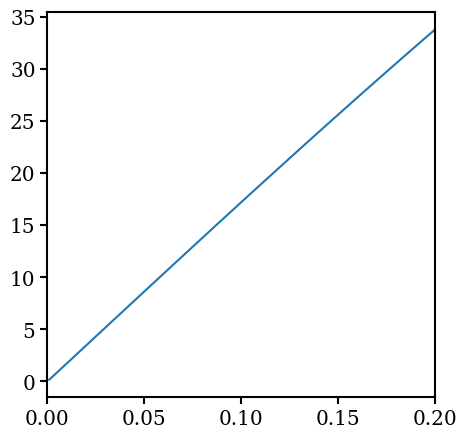

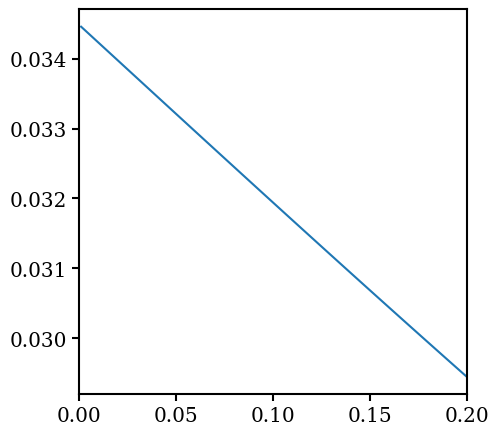

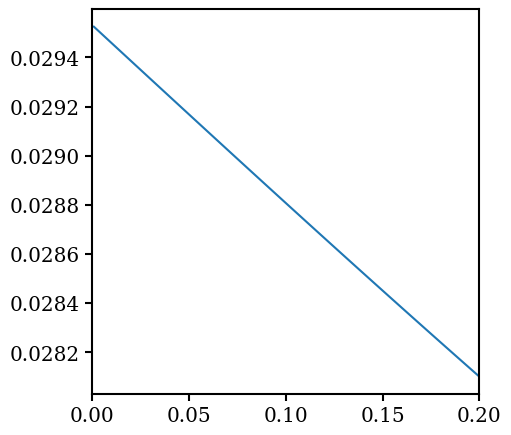

In [276]:
from astropy.cosmology import Planck18, WMAP7, FlatLambdaCDM

cosmos_flat = FlatLambdaCDM(H0=70, Om0=0.3)

zred_bins = np.linspace(0.001, 0.2,100)

p18_DLs = Planck18.luminosity_distance(zred_bins).value
w7_DLs = WMAP7.luminosity_distance(zred_bins).value
flat_DLs = cosmos_flat.luminosity_distance(zred_bins).value

# their cosmology (example)
plt.figure(figsize = (5,5))
plt.plot(zred_bins, p18_DLs -  w7_DLs)
plt.xlim([0,0.2])
plt.show()

##how much does this translate to an offset in absolute magnitudes
plt.figure(figsize = (5,5))
plt.plot(zred_bins, 0.4 * 5 * np.log10(p18_DLs / w7_DLs  ) )
plt.xlim([0,0.2])
plt.show()

plt.figure(figsize = (5,5))
plt.plot(zred_bins, 0.4 * 5 * np.log10(p18_DLs / flat_DLs  ) )
plt.xlim([0,0.2])
plt.show()




In [96]:
### ahhh how does the updated stellar mass relation from Mia de los reyes compare to the old one I was using!!

In [127]:
from desi_lowz_funcs import get_stellar_mass_mia

main = main[main["DWARF_MASKBIT"] == 0]

gr_color = main["MAG_G"].data - main["MAG_R"].data

g_mag = main["MAG_G"].data
d_in_mpc = main["LUMI_DIST_MPC"].data
zreds = main["Z_CMB"].data

from desi_lowz_funcs import g_kcorr

d_in_pc = d_in_mpc * 1e6
kg = g_kcorr(gr_color,zreds)

Mg = g_mag + 5 - 5*np.log10(d_in_pc) - kg


In [128]:
log_mstar_OLD = (1.433 * gr_color) + 0.00153 * (Mg**2) - (0.335 * Mg) + 2.072

log_mstar_NEW = get_stellar_mass_mia(gr_color, g_mag, zreds, d_in_mpc=d_in_mpc, input_zred=False)

In [129]:
len(log_mstar_NEW[log_mstar_NEW < 9.25])

212708

In [131]:
len(log_mstar_NEW)

218926

In [132]:
212708/218926

0.9715977088148506